# World Cup Prediction: Match Model, Bracket Simulation, and Cross-Tournament Analysis

## Learning objectives
- Build a leak-free, temporally-split 1X2 match model for the World Cup using
  Elo and FIFA squad-strength features.
- Show that FIFA player ratings add predictive value over a strong Elo-only
  baseline on two held-out tournaments (2018 and 2022).
- Turn calibrated match probabilities into round-advancement and title odds via
  Monte-Carlo bracket simulation.
- Test whether continental-tournament form (Euro, Copa America, etc.) predicts
  World Cup performance.

## Outline
1. Imports and configuration
2. Data loading and inspection
3. Feature matrix (target, features, class balance)
4. Modelling and baselines (held-out tournaments)
5. Calibration
6. Bracket simulation (title probabilities)
7. Cross-tournament correlation study
8. Conclusion

## Introduction
Every prediction is made strictly before kickoff. The training backbone is all
competitive international matches before the target tournament (each enriched
with the FIFA edition active at its date and a pre-match World-Football Elo);
the test set is the tournament itself. Regulation results (90 minutes) are the
target, encoded H = 0, D = 1, A = 2. Reusable logic lives in ``src/worldcup``;
this notebook only orchestrates and reports.

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

from src.worldcup import config as C
from src.worldcup.data import load_wc_matches, load_fifa_players, load_intl_results
from src.worldcup.features import build_dataset, FEATURES
from src.worldcup.model import train_eval
from src.worldcup.simulate import simulate
from src.worldcup.cross_tournament import cross_tournament_panel, analyse_correlation

RANDOM_STATE = 7
N_SIMS = 10000
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
print("FIFA editions available:", sorted(load_fifa_players()["edition"].unique()))
print("Modelled cycles -> editions:", C.CYCLE_EDITIONS)

FIFA editions available: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Modelled cycles -> editions: {2018: [2017, 2018], 2022: [2019, 2020, 2021, 2022]}


## 2. Data loading and inspection
Three sources joined on a single canonical country naming: the World Cup
structured data (matches, bracket), the international-results table (training
backbone, Elo, continental form), and FIFA player ratings (squad strength).

In [2]:
wc = load_wc_matches()
intl = load_intl_results()
print("World Cup matches (men's):", wc.shape)
print("International matches:", intl.shape, "| date range:",
      intl["date"].min().date(), "->", intl["date"].max().date())
wc[["tournament_id", "match_name", "stage_name", "score", "extra_time", "result"]].head()

World Cup matches (men's): (960, 38)
International matches: (49306, 15) | date range: 1872-11-30 -> 2026-06-03


,tournament_id,match_name,stage_name,score,extra_time,result
0,WC-1930,France vs Mexico,group stage,4–1,0,H
1,WC-1930,United States vs Belgium,group stage,3–0,0,H
2,WC-1930,Yugoslavia vs Brazil,group stage,2–1,0,H
3,WC-1930,Romania vs Peru,group stage,3–1,0,H
4,WC-1930,Argentina vs France,group stage,1–0,0,H


The regulation target is recovered without leakage: a knockout match that went
to extra time was level after 90 minutes, so its regulation result is a draw.

In [3]:
et = wc[wc["extra_time"] == 1]
print(f"Extra-time matches: {len(et)}; all labelled regulation draw: "
      f"{(et['result'] == 'D').all()}")
wc["result"].value_counts().rename("count").to_frame()

Extra-time matches: 73; all labelled regulation draw: True


,count
result,
H,499
D,246
A,215


## 3. Feature matrix
``build_dataset`` returns the pre-tournament training backbone and the held-out
tournament, both in one symmetric representation: differences (team1 - team2) of
Elo and FIFA squad-strength, plus a signed ``home_field`` (host) term.

In [4]:
data = build_dataset(2022)
train, test = data["train"], data["test"]
X_test, y_test = test[FEATURES], test["y"]
print("FIFA edition used for 2022 squad strength:", data["edition"])
print("Backbone training matches:", len(train), "| 2022 test matches:", len(test))
print("Features:", FEATURES)
test[["team1", "team2", "stage", "d_elo", "d_ovr_top23", "home_field", "y"]].head()

FIFA edition used for 2022 squad strength: 2022
Backbone training matches: 1370 | 2022 test matches: 64
Features: ['d_elo', 'home_field', 'd_ovr_top23', 'd_ovr_top11', 'd_ovr_top3', 'd_gk', 'd_def_top', 'd_mid_top', 'd_att_top', 'd_depth80']


,team1,team2,stage,d_elo,d_ovr_top23,home_field,y
0,Qatar,Ecuador,group stage,-121.504714,-5.652174,1.0,2
1,England,Iran,group stage,76.579796,14.745342,0.0,0
2,Senegal,Netherlands,group stage,-274.819630,-4.391304,0.0,2
3,United States,Wales,group stage,64.327862,1.521739,0.0,1
4,Argentina,Saudi Arabia,group stage,445.876012,13.565217,0.0,2


Class balance of the regulation target on the held-out tournament. Draws are
the minority class, as expected in football.

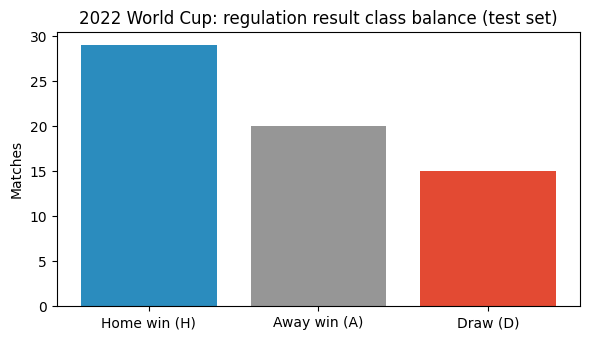

,matches
y,
Home win (H),29
Away win (A),20
Draw (D),15


In [5]:
labels = {0: "Home win (H)", 1: "Draw (D)", 2: "Away win (A)"}
counts = y_test.map(labels).value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(counts.index, counts.values, color=["#2b8cbe", "#969696", "#e34a33"])
ax.set_title("2022 World Cup: regulation result class balance (test set)")
ax.set_ylabel("Matches")
plt.tight_layout(); plt.show()
counts.to_frame("matches")

## 4. Modelling and baselines
Multinomial logistic regression on standardised features, trained on the mirrored
backbone (orientation-invariant) and calibrated on a temporal tail. It is
compared against two baselines on the held-out tournament: an Elo-only model
(the strong baseline; bookmaker odds are unavailable for historical World Cups in
these free sources) and the class-prior (the sanity floor). Primary metric is
multi-class log-loss, then Brier, then accuracy (lower is better for the first
two).

In [6]:
res22 = train_eval(2022)
res18 = train_eval(2018)
results_df = pd.concat([
    res18["results"].assign(tournament=2018),
    res22["results"].assign(tournament=2022),
], ignore_index=True)[["tournament", "model", "log_loss", "brier", "accuracy"]]
results_df

/sessions/eager-affectionate-noether/.local/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/sessions/eager-affectionate-noether/.local/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,tournament,model,log_loss,brier,accuracy
0,2018,full (Elo + FIFA strength),0.950548,0.565079,0.562500
1,2018,baseline: Elo-only,0.986797,0.583823,0.515625
2,2018,baseline: class-prior,1.104718,0.672044,0.390625
3,2022,full (Elo + FIFA strength),1.003818,0.590911,0.578125
4,2022,baseline: Elo-only,1.032470,0.614010,0.546875
5,2022,baseline: class-prior,1.063341,0.642906,0.453125


The full model beats both baselines on log-loss and Brier in both held-out
tournaments, so FIFA squad strength carries information beyond Elo alone.

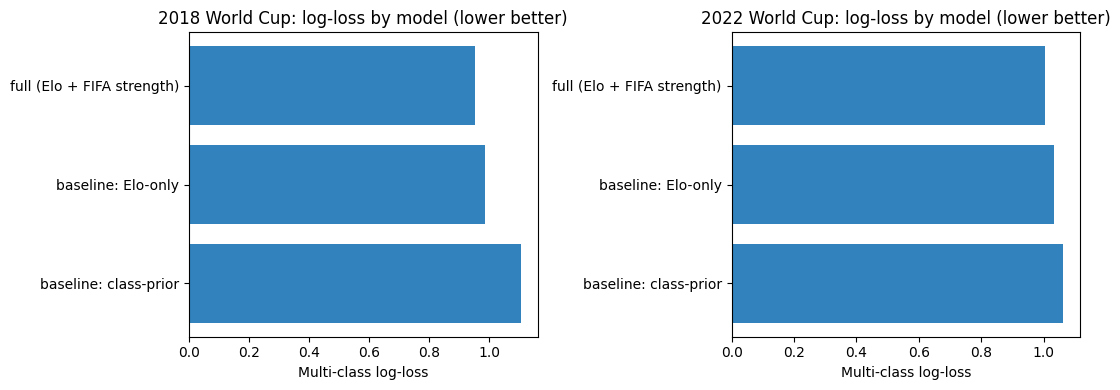

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, yr in zip(axes, [2018, 2022]):
    sub = results_df[results_df["tournament"] == yr]
    ax.barh(sub["model"], sub["log_loss"], color="#3182bd")
    ax.invert_yaxis()
    ax.set_title(f"{yr} World Cup: log-loss by model (lower better)")
    ax.set_xlabel("Multi-class log-loss")
plt.tight_layout(); plt.show()

## 5. Calibration
Reliability of the predicted team1-win probability on the held-out tournaments
(one-vs-rest). "team1" is just the orientation stored in the source row, not a
team with home advantage -- World Cup venues are neutral. Points near the
diagonal indicate well-calibrated probabilities, which matters more than raw
accuracy for downstream betting-market use.

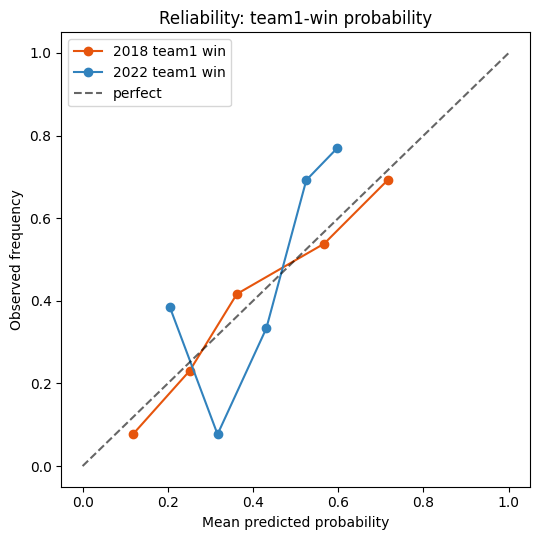

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for res, yr, col in [(res18, 2018, "#e6550d"), (res22, 2022, "#3182bd")]:
    t = res["test"]
    frac, mean_pred = calibration_curve((t["y"] == 0).astype(int), t["p_team1"],
                                        n_bins=5, strategy="quantile")
    ax.plot(mean_pred, frac, "o-", color=col, label=f"{yr} team1 win")
ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Reliability: team1-win probability"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Bracket simulation
The calibrated match model feeds a Monte-Carlo simulation of the actual group
draw and the standard 32-team bracket. Group matches are sampled as 1X2; in
knockouts a draw cannot stand, so P(advance) = P(win) + 0.5 * P(draw).

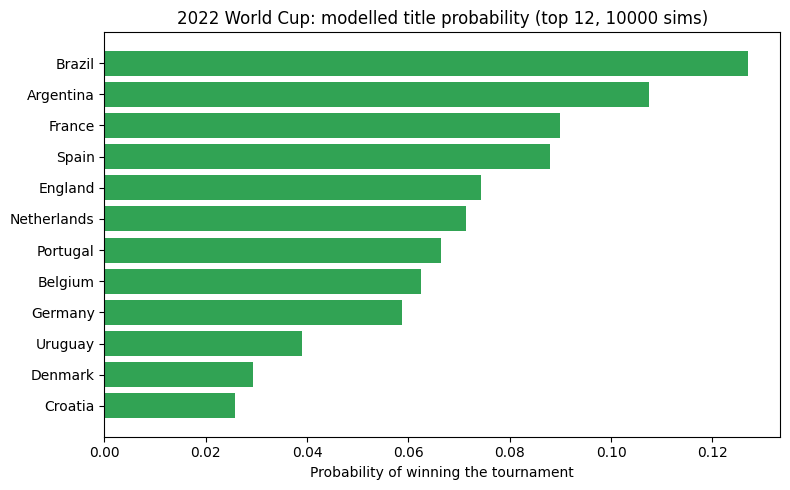

,team,R16,QF,SF,Final,Champion
0,Brazil,0.8453,0.5408,0.3321,0.2049,0.1270
1,Argentina,0.8494,0.5322,0.3337,0.1863,0.1074
2,France,0.8361,0.4957,0.3030,0.1654,0.0899
3,Spain,0.8133,0.4929,0.2744,0.1610,0.0879
4,England,0.8295,0.5111,0.2748,0.1442,0.0743
5,Netherlands,0.8286,0.5094,0.2736,0.1332,0.0714
6,Portugal,0.7948,0.4431,0.2410,0.1345,0.0664
7,Belgium,0.7589,0.3982,0.2132,0.1195,0.0625
8,Germany,0.7280,0.4132,0.2201,0.1168,0.0588
9,Uruguay,0.6763,0.3384,0.1682,0.0817,0.0391


In [9]:
sim22 = simulate(2022, res22["model"], n_sims=N_SIMS, seed=RANDOM_STATE)
top = sim22.head(12)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["team"], top["Champion"], color="#31a354")
ax.invert_yaxis()
ax.set_title(f"2022 World Cup: modelled title probability (top 12, {N_SIMS} sims)")
ax.set_xlabel("Probability of winning the tournament")
plt.tight_layout(); plt.show()
sim22.head(12)

In [10]:
champ = sim22[sim22["team"] == "Argentina"].iloc[0]
print(f"Actual 2022 winner Argentina: P(champion) = {champ['Champion']:.3f}, "
      f"P(reach final) = {champ['Final']:.3f}, P(reach semi) = {champ['SF']:.3f}")

Actual 2022 winner Argentina: P(champion) = 0.107, P(reach final) = 0.186, P(reach semi) = 0.334


## 7. Cross-tournament correlation study
Does continental-tournament form predict World Cup performance? For every team
in every World Cup since 1998, we compare its World Cup points-per-game with its
most-recent continental-campaign ppg, its recent competitive ppg, and its
pre-tournament Elo (a benchmark that integrates all prior results).

In [11]:
panel = cross_tournament_panel()
corr = analyse_correlation(panel)
corr

,predictor,n,pearson,spearman
0,continental campaign ppg,195,-0.020427,-0.047080
1,recent competitive ppg (24m),221,0.090908,0.085734
2,pre-tournament Elo (benchmark),224,0.515671,0.533908


Raw continental-tournament ppg barely correlates with World Cup ppg, while
pre-tournament Elo correlates strongly. The cross-tournament signal is real but
is already absorbed into overall team strength (Elo and FIFA ratings), so adding
raw continental form as a separate model feature would add noise rather than
signal. This justifies the model design.

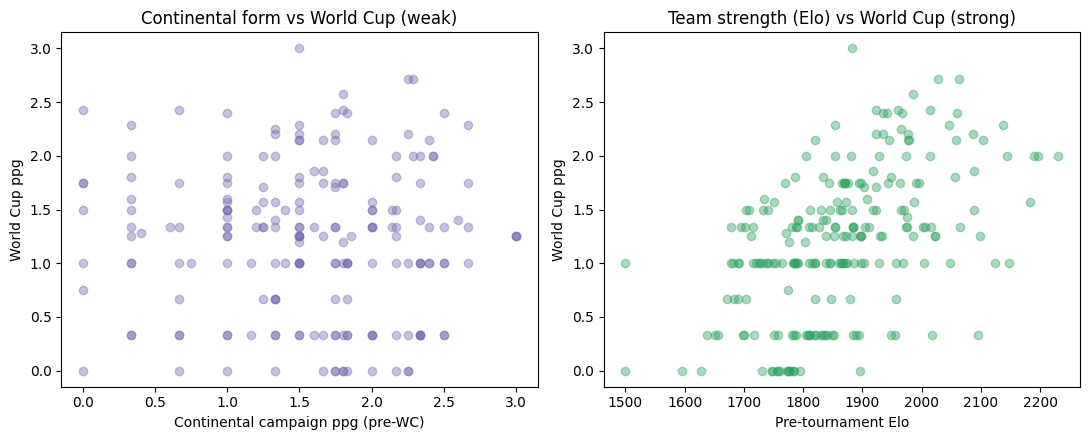

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sub = panel.dropna(subset=["cont_ppg"])
axes[0].scatter(sub["cont_ppg"], sub["wc_ppg"], alpha=0.4, color="#756bb1")
axes[0].set_xlabel("Continental campaign ppg (pre-WC)")
axes[0].set_ylabel("World Cup ppg")
axes[0].set_title("Continental form vs World Cup (weak)")
sub2 = panel.dropna(subset=["pre_elo"])
axes[1].scatter(sub2["pre_elo"], sub2["wc_ppg"], alpha=0.4, color="#2ca25f")
axes[1].set_xlabel("Pre-tournament Elo")
axes[1].set_ylabel("World Cup ppg")
axes[1].set_title("Team strength (Elo) vs World Cup (strong)")
plt.tight_layout(); plt.show()

## 8. Conclusion
- A temporally-split match model using pre-match Elo and FIFA squad strength
  beats both the Elo-only and class-prior baselines on log-loss and Brier in
  both held-out tournaments (2018 and 2022).
- FIFA player ratings add genuine predictive value beyond Elo.
- The bracket simulation produces plausible title odds; the eventual champions
  (France 2018, Argentina 2022) ranked among the top few teams.
- Continental-tournament form does not directly predict World Cup performance,
  but overall team strength (which absorbs that form) does.

### Next steps to tune first
- ``config.CYCLE_EDITIONS``: add FIFA 14-16 to lengthen the 2018 cycle window.
- ``elo._k_importance`` / ``HOME_ADV``: the Elo weighting drives the baseline.
- ``model.train_eval``: try gradient boosting and isotonic-vs-sigmoid calibration.
- Extend to the 2026 World Cup once FIFA 23-26 ratings and the draw are added.